In [2]:
import json
import matplotlib.pyplot as plt

In [3]:
with open('results/experiment_results_1771470240.jsonl', 'r') as f:
    lines = f.readlines()
results = [json.loads(line) for line in lines]
print(results)

[{'beta': 0, 'alpha': 2.35, 'mse_runs': [0.45122564106947116, 0.46216695728403323, 0.49191668221427265, 0.4600027646281321, 0.481518800894865, 0.460951187965412, 0.46284436198143014, 0.48060385010250306, 0.49572928007459793, 0.48099465832579924], 'mean_mse': 0.47279541845405165, 'std_mse': 0.01441201607365214, 'mean_e_ICL_trace': 1.5384548561234708, 'std_e_ICL_trace': 0.006804260435618517}, {'beta': 0, 'alpha': 5.5, 'mse_runs': [0.3283841149758965, 0.3228152939586338, 0.32826385458110013, 0.32746930995248547, 0.33013716538461885, 0.3129958216380817, 0.3362732248900943, 0.31951021358765597, 0.307884662591658, 0.3388250157122005], 'mean_mse': 0.32525586772724246, 'std_mse': 0.009187495223075182, 'mean_e_ICL_trace': 1.559450110835008, 'std_e_ICL_trace': 0.010568227413897282}, {'beta': 0, 'alpha': 9.62, 'mse_runs': [0.5149320552311989, 0.4866913952721306, 0.5281871338219633, 0.5077215918569915, 0.5015927674227989, 0.5263822833418721, 0.4823400197080867, 0.5118315065144832, 0.49601961100430

In [21]:
results_dict = {}
for result in results:
    beta = result['beta']
    alpha = result['alpha']
    value = result['mean_e_ICL_trace']
    results_dict[(beta, alpha)] = value

results_dict

{(0, 2.35): 1.5384548561234708,
 (0, 5.5): 1.559450110835008,
 (0, 9.62): 1.5948585350413829,
 (0, 22.7): 1.6739292915863841,
 (0, 100): 1.863540556212169,
 (0, 1000): 1.9934100590027892,
 (0.1, 2.35): 1.5382127146801392,
 (0.1, 5.5): 1.5590043787196959,
 (0.1, 9.62): 1.5940982121375686,
 (0.1, 22.7): 1.672526706259062,
 (0.1, 100): 1.8608366163488939,
 (0.1, 1000): 1.9898651525009232,
 (0.25, 2.35): 1.5369414721026464,
 (0.25, 5.5): 1.5566642851143073,
 (0.25, 9.62): 1.590106516892544,
 (0.25, 22.7): 1.6651631332906205,
 (0.25, 100): 1.8466409320666979,
 (0.25, 1000): 1.971254393366125,
 (0.5, 2.35): 1.5324013200401723,
 (0.5, 5.5): 1.5483068079522055,
 (0.5, 9.62): 1.5758504624460266,
 (0.5, 22.7): 1.6388646584033293,
 (0.5, 100): 1.7959420596302842,
 (0.5, 1000): 1.9047873964561326,
 (0.75, 2.35): 1.5248343999360494,
 (0.75, 5.5): 1.5343776793487027,
 (0.75, 9.62): 1.552090371701831,
 (0.75, 22.7): 1.5950338669245099,
 (0.75, 100): 1.711443938902928,
 (0.75, 1000): 1.794009068272811

In [ ]:
def plot_experiments_results(jsonl_file_path):
    with open(jsonl_file_path, 'r') as f:
        lines = f.readlines()
    results = [json.loads(line) for line in lines]

    print(results)

    results_dict = {}
    for result in results:
        strength = result.get('strength', 0)
        rho = result['rho']
        results_dict[(strength, rho)] = results_dict.get((strength, rho), {})
        beta = float(result['beta'])
        alpha = float(result['alpha'])
        value = float(result['mean_mse'])
        # value = result['mean_e_ICL_trace']
        results_dict[(strength, rho)][(beta, alpha)] = value

    betas = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
    alphas = [2.35, 5.5, 9.62, 22.7, 100, 1_000]

    for strength in [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]:
        for rho in [0.1, 0.5, 1.0, 2.0]:
            plt.figure(figsize=(10, 6))
            for beta in betas:
                avg_values = [results_dict[(strength, rho)][(beta, alpha)] for alpha in alphas]
                plt.plot(alphas, avg_values, marker='o', label=f'Beta={beta}')
            plt.xscale('log')
            plt.xlabel('alpha')
            plt.ylabel('Average Value')
            plt.title(f'Average Value vs. alpha for Different Beta Values {strength}, {rho}')
            plt.legend()
            plt.grid()
            plt.show()

[{'beta': 0, 'alpha': 2.35, 'rho': 0.1, 'strength': 0.1, 'mse_runs': [0.11138462711502507, 0.08569868669057183, 0.10476679032652333, 0.09424179174825703, 0.09311968678095099, 0.1277310271737934, 0.08114552826540805, 0.10058546864593909, 0.15993101641329804, 0.13134083216669257, 0.0881847050719154, 0.08523995244447832, 0.11783220155367725, 0.12299352185873563, 0.11031468508090886, 0.12652546435773515, 0.10136164694697182, 0.12360220341869173, 0.13395730058419436, 0.1249341254710888], 'mean_mse': 0.11124456310574285, 'std_mse': 0.01994397041188342, 'mean_e_ICL_trace': 1.1283564465858507, 'std_e_ICL_trace': 0.005619803322539224}, {'beta': 0, 'alpha': 2.35, 'rho': 0.1, 'strength': 0.25, 'mse_runs': [0.08865974850964158, 0.11985505001991571, 0.10007950560071721, 0.09847857479514187, 0.09956205172237396, 0.08017628503409252, 0.11687986518998617, 0.16338120309769708, 0.12920669184483166, 0.10965169509660573, 0.11456673053572551, 0.10653567820714979, 0.11403256968228796, 0.11301986841437228, 0

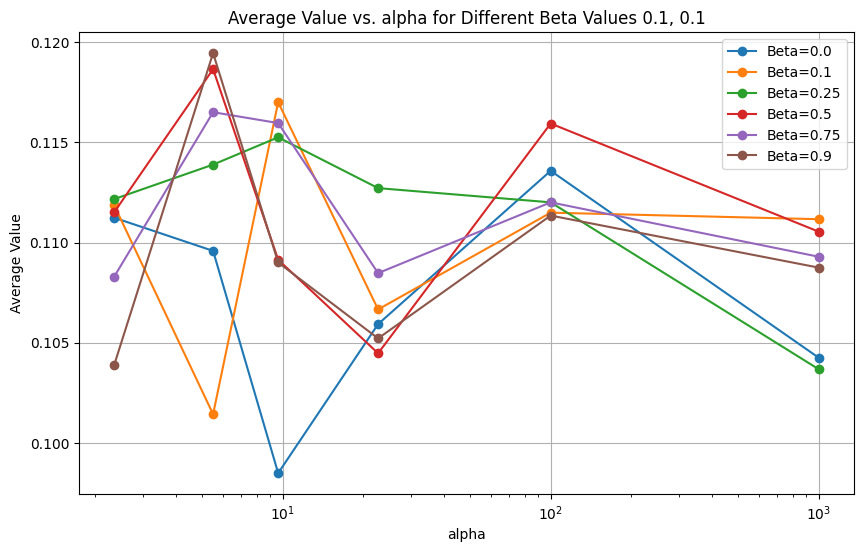

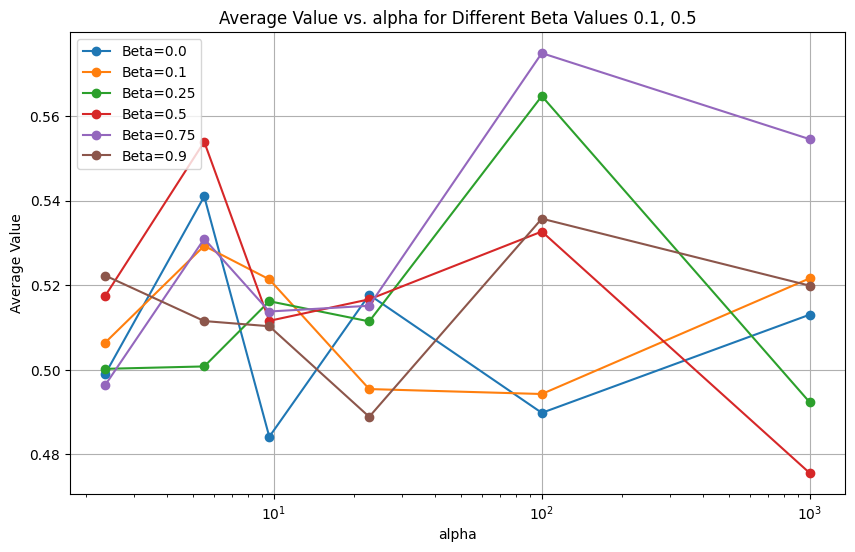

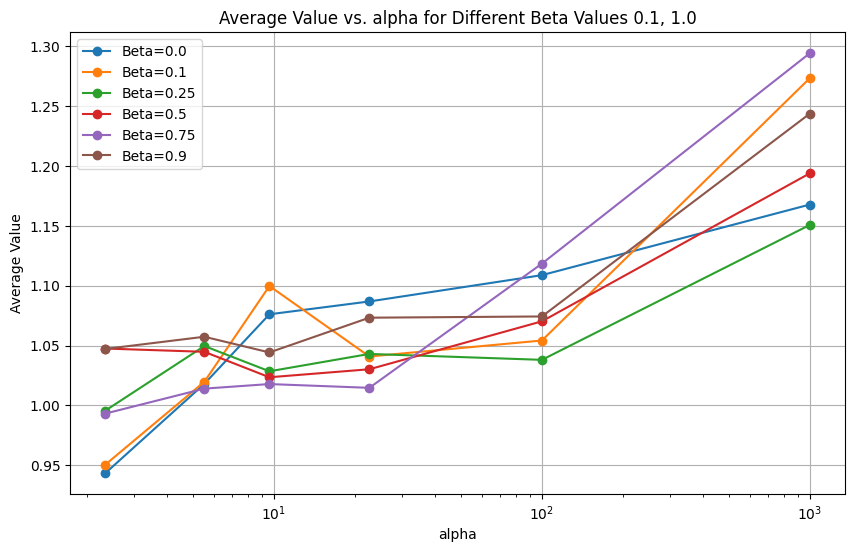

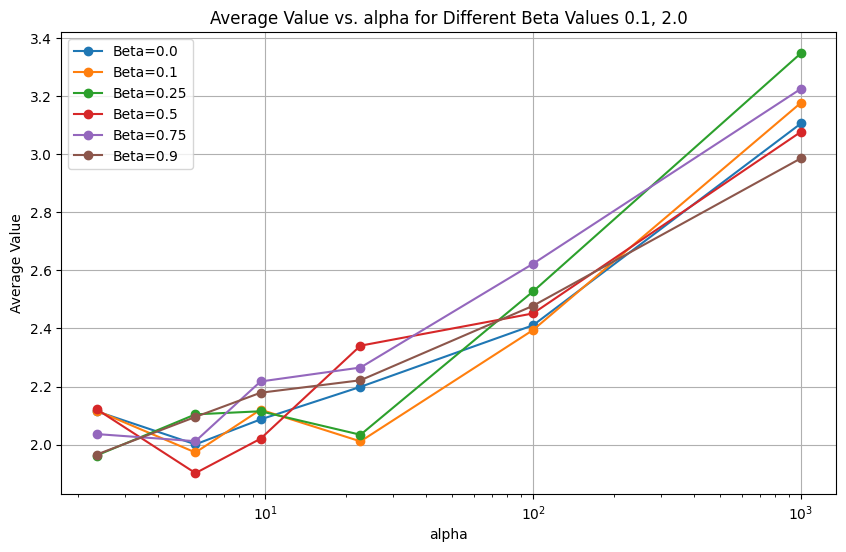

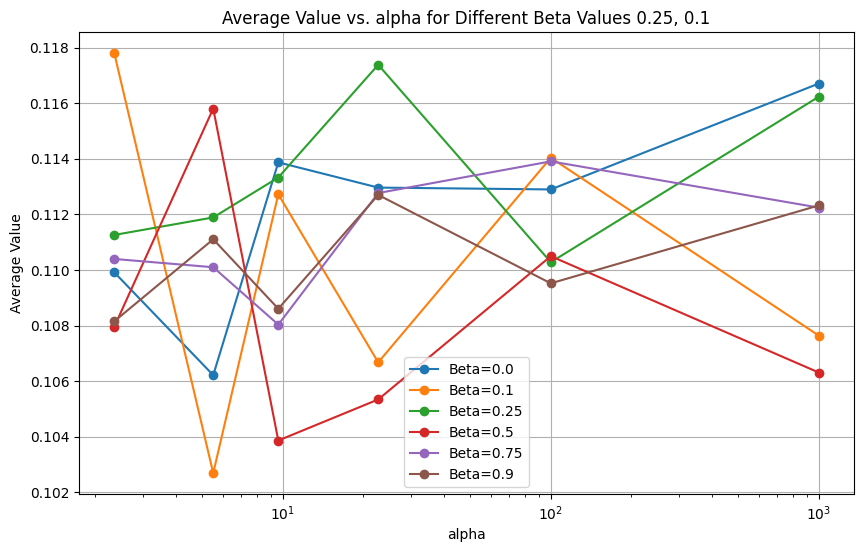

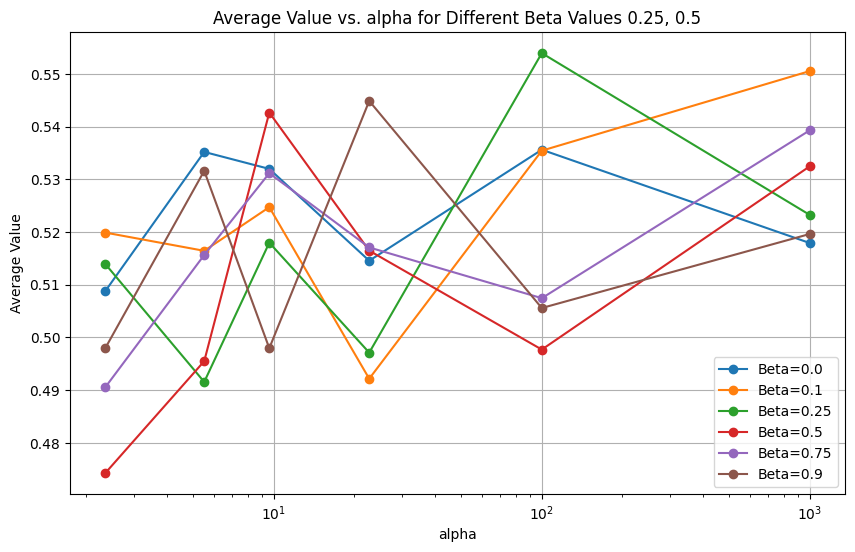

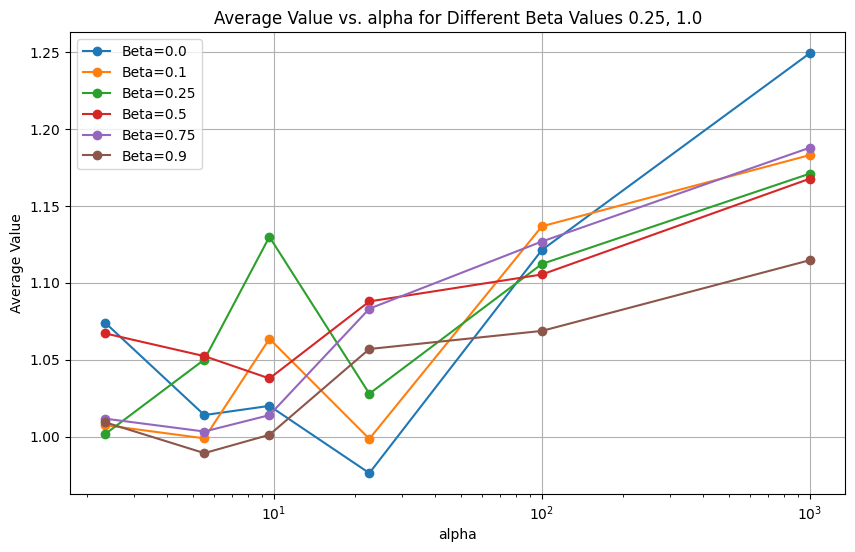

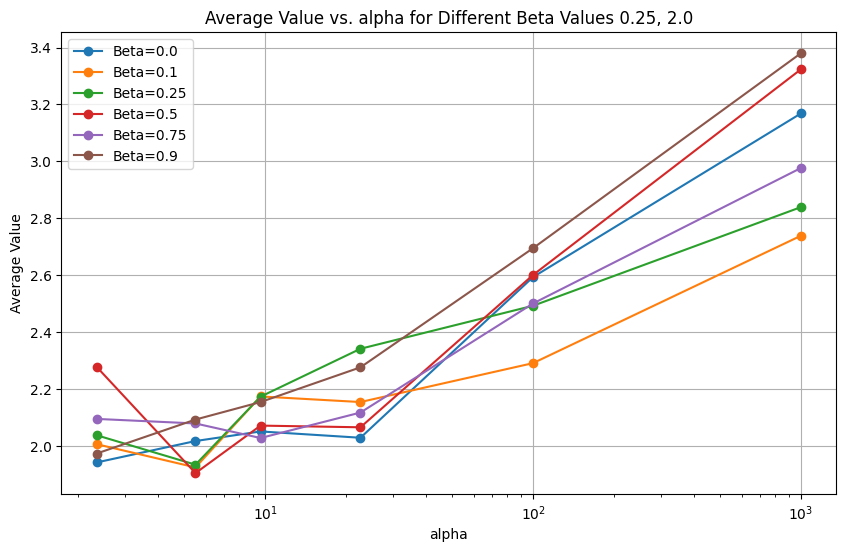

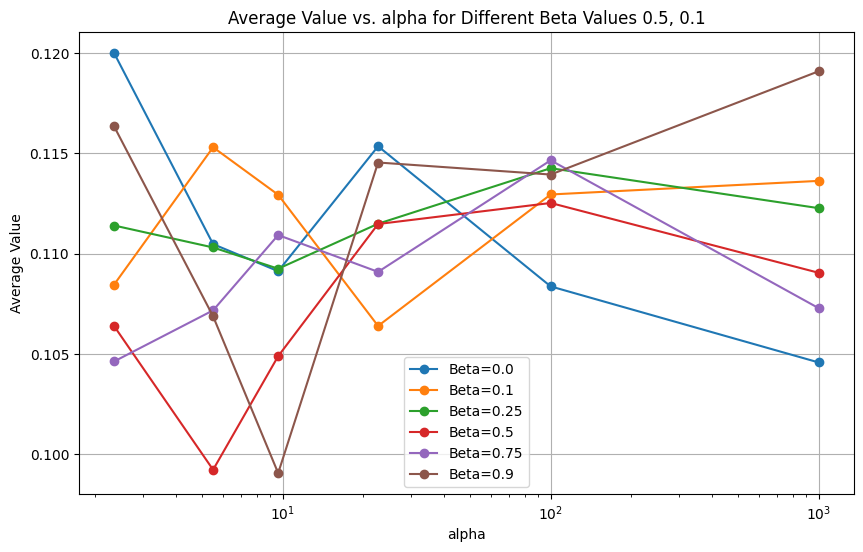

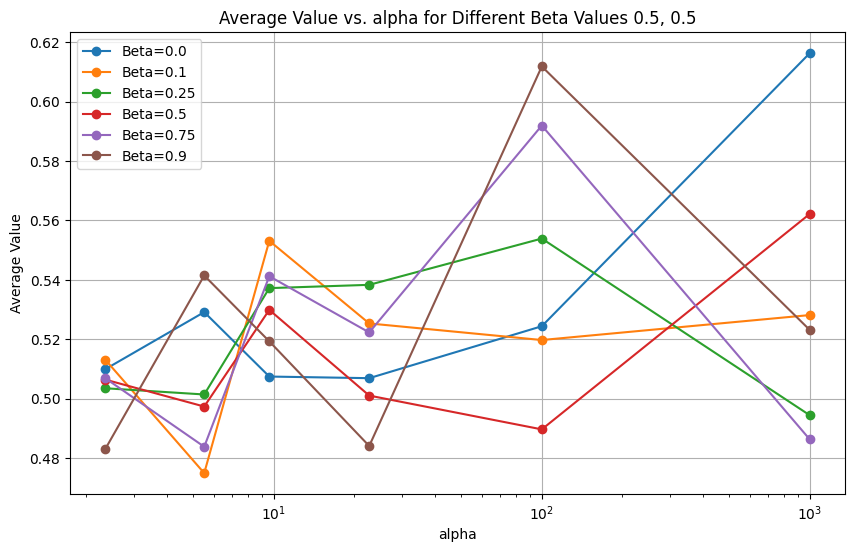

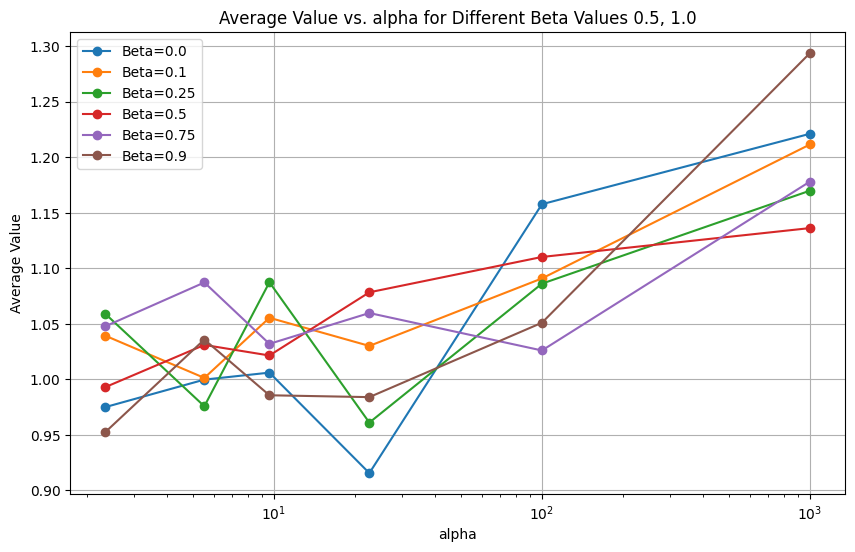

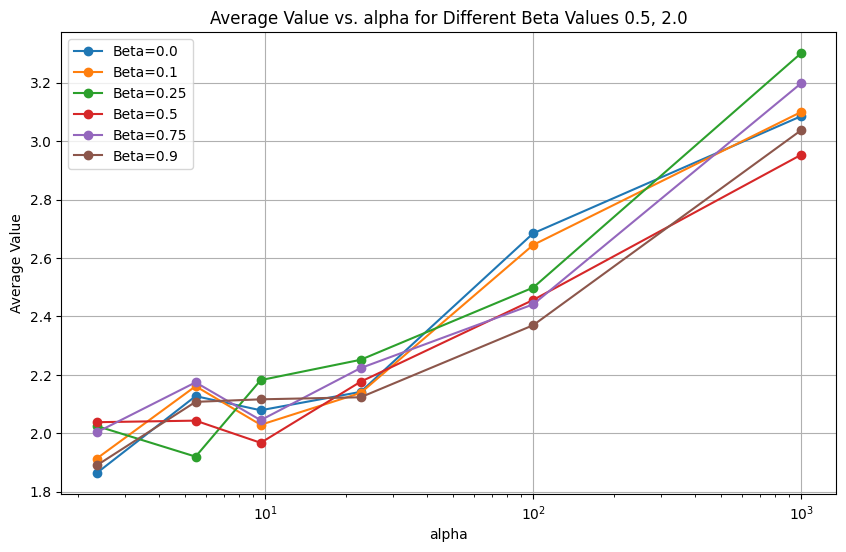

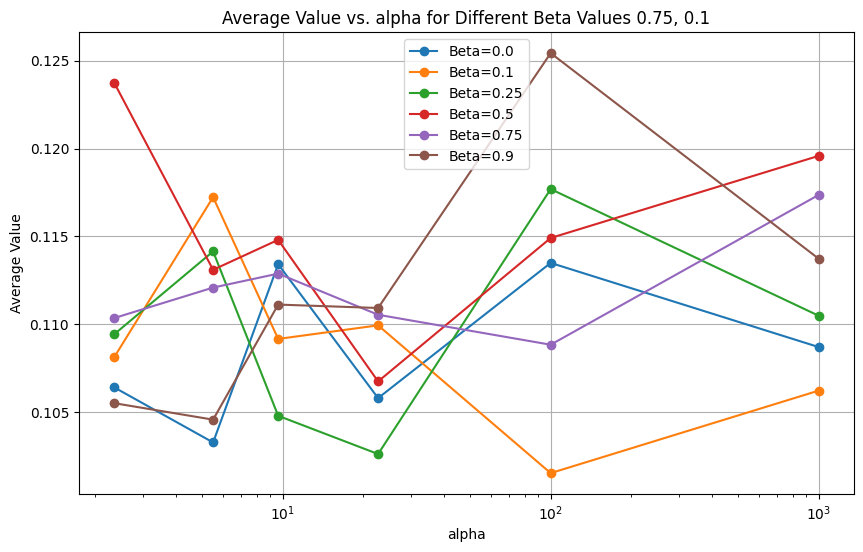

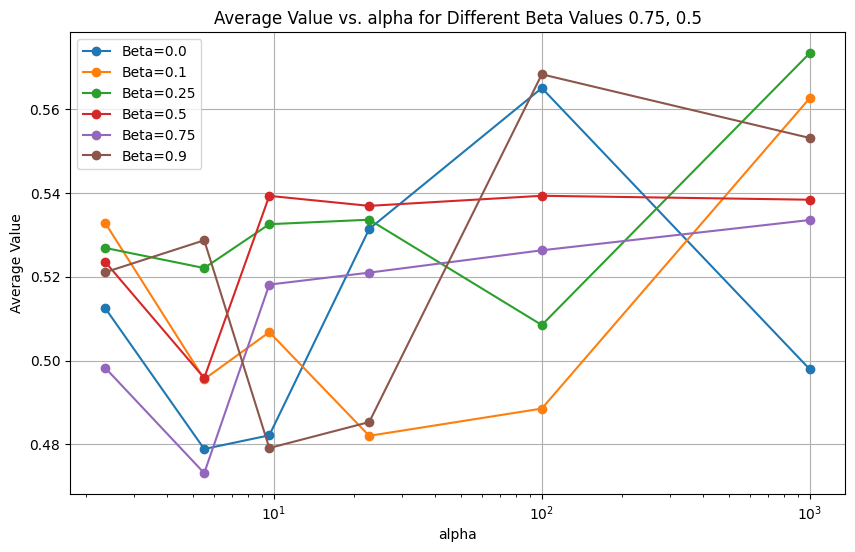

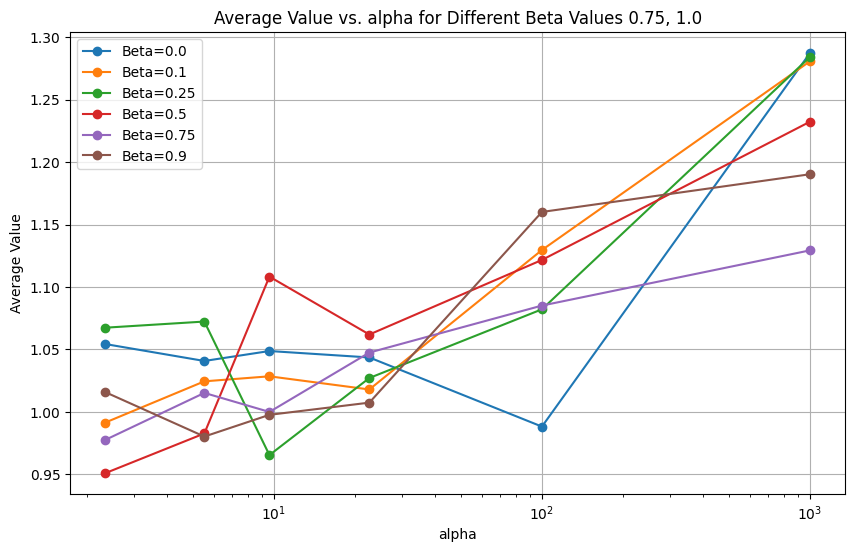

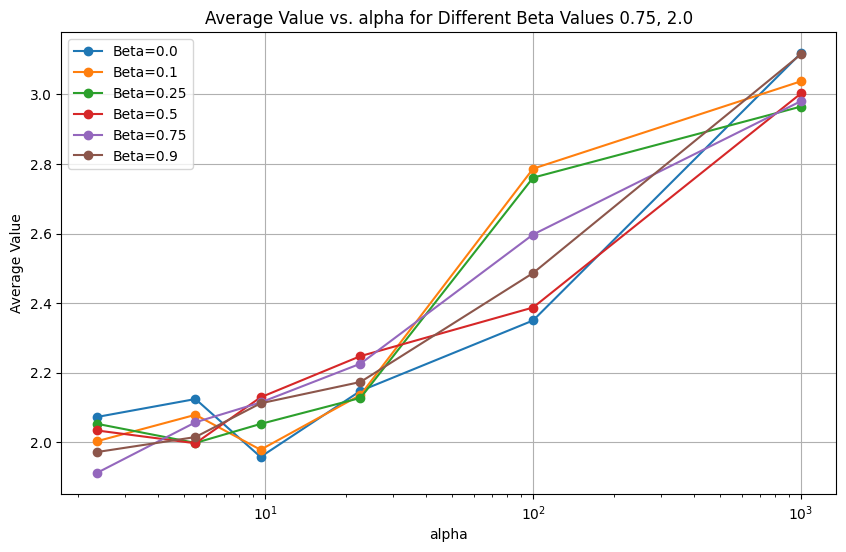

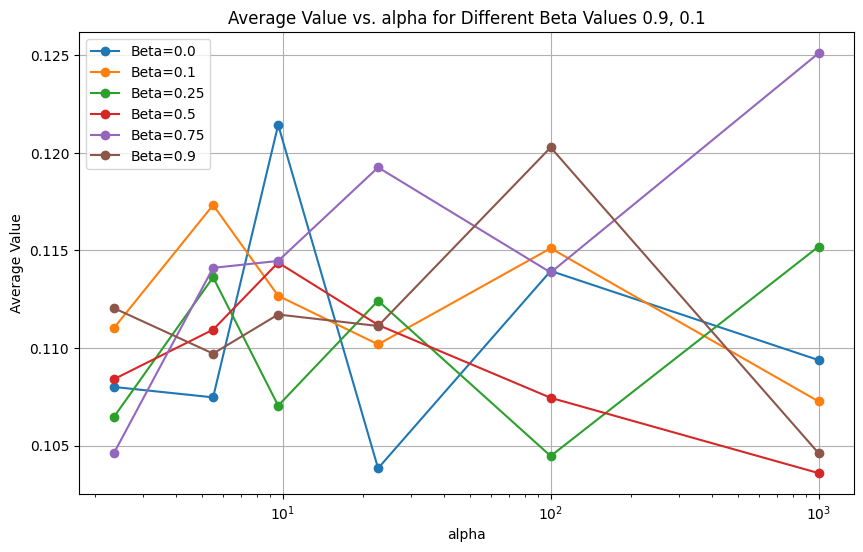

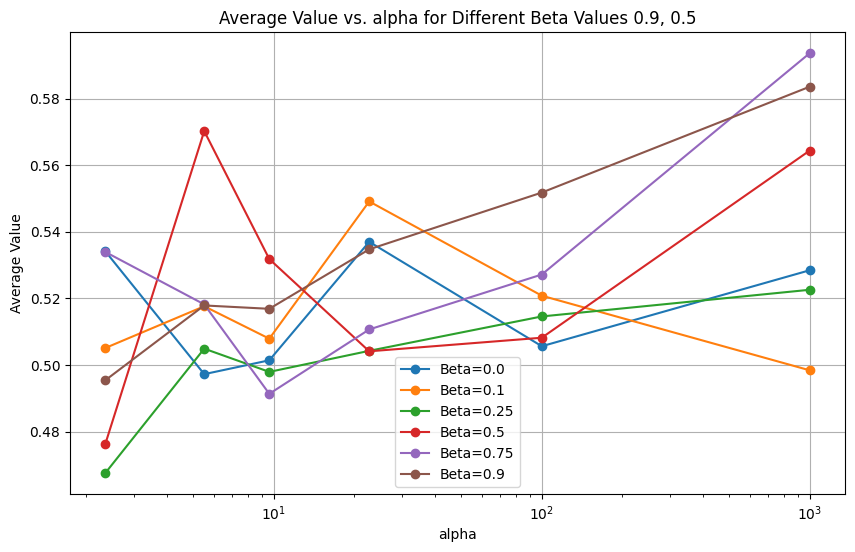

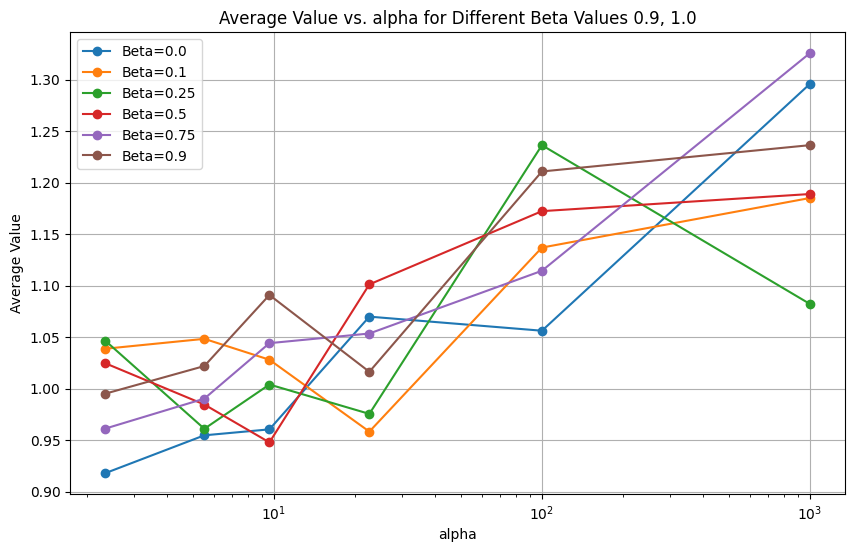

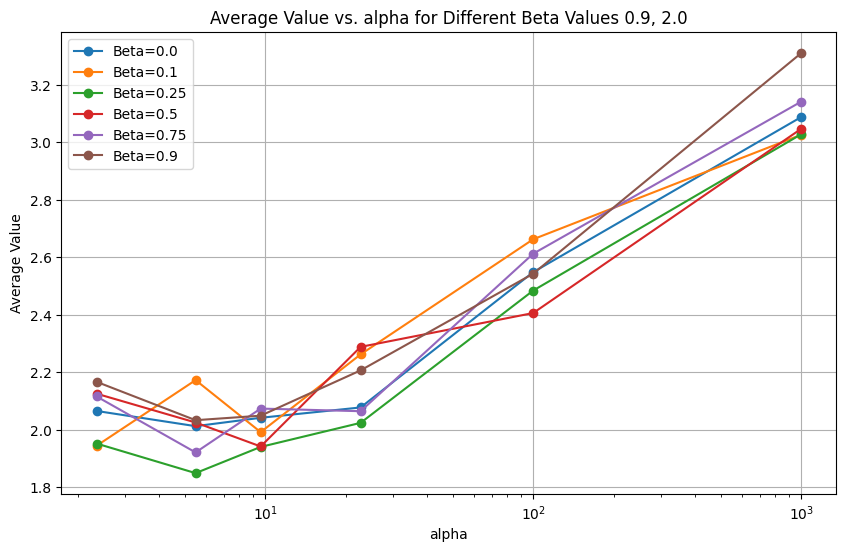

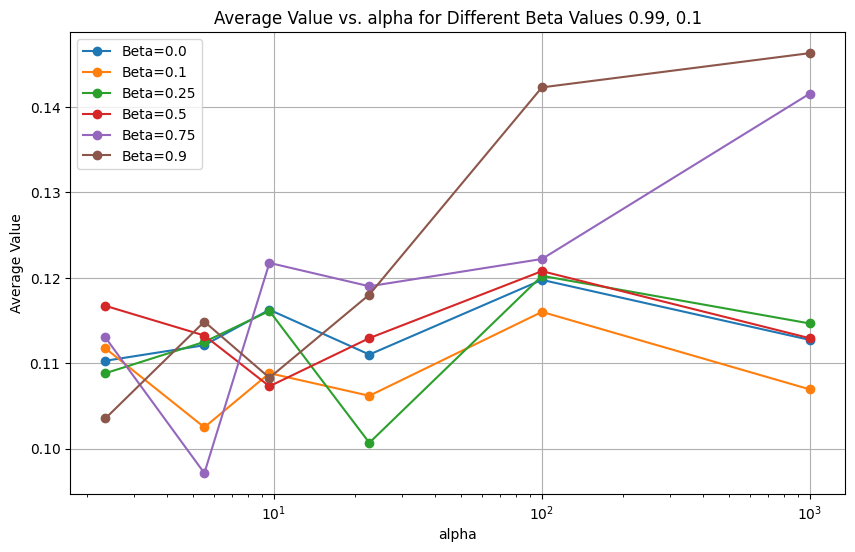

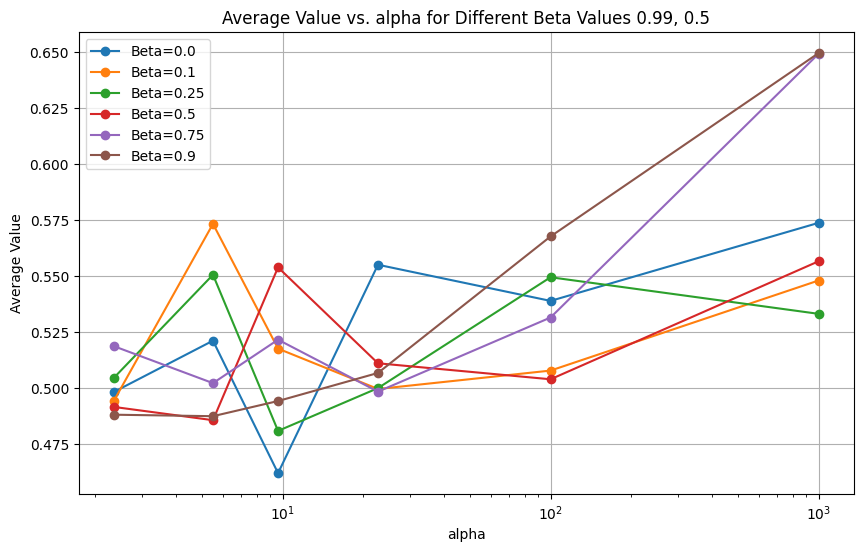

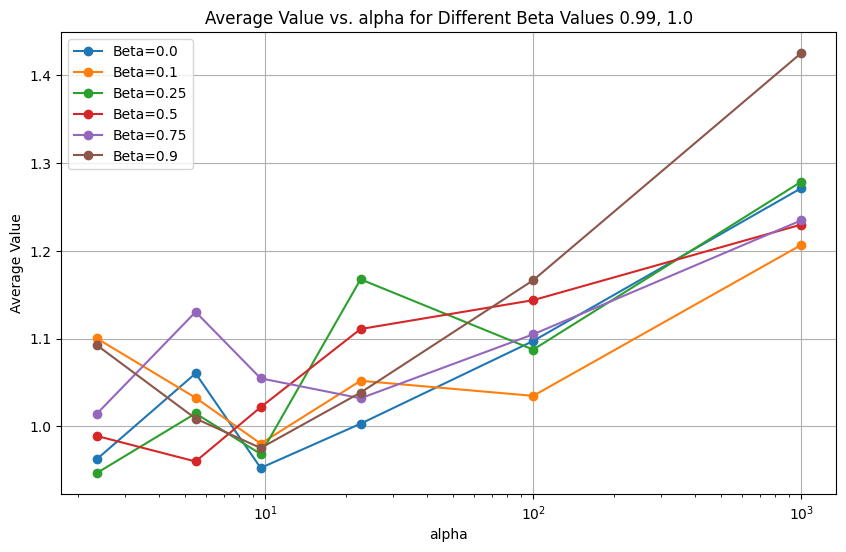

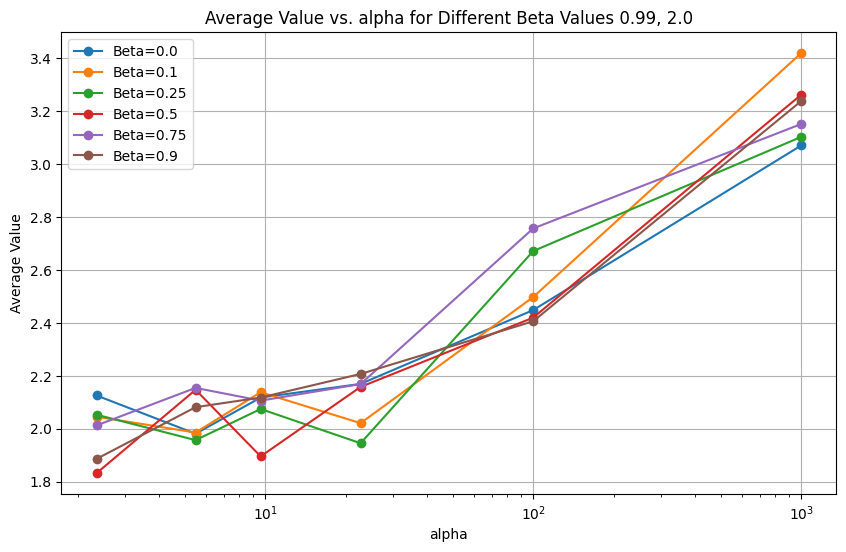

KeyError: (1.0, 0.1)

<Figure size 1000x600 with 0 Axes>

In [50]:
plot_experiments_results('results/experiment_results_1772667611.jsonl')